In [9]:
import os

print(os.listdir("../Data"))

['train.csv']


In [10]:
import pandas as pd

df = pd.read_csv("../Data/train.csv")

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [11]:
print(df.shape)

(9800, 18)


In [12]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [13]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [17]:
df=df.dropna()

In [18]:
print(df.isnull().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


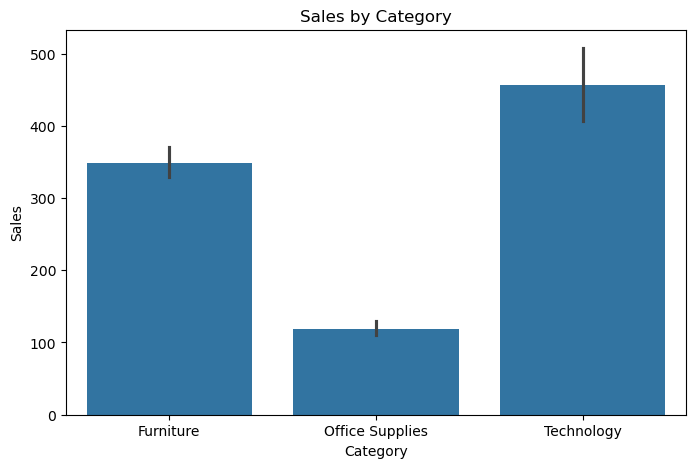

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x=df['Category'], y=df['Sales'])

plt.title("Sales by Category")

plt.show()

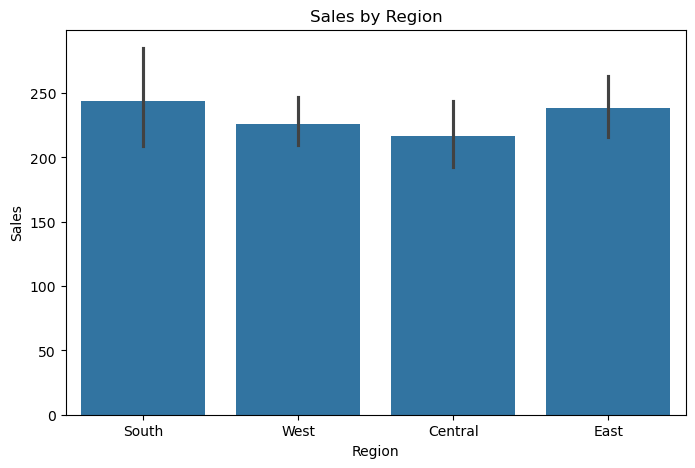

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(x=df['Region'], y=df['Sales'])

plt.title("Sales by Region")

plt.show()

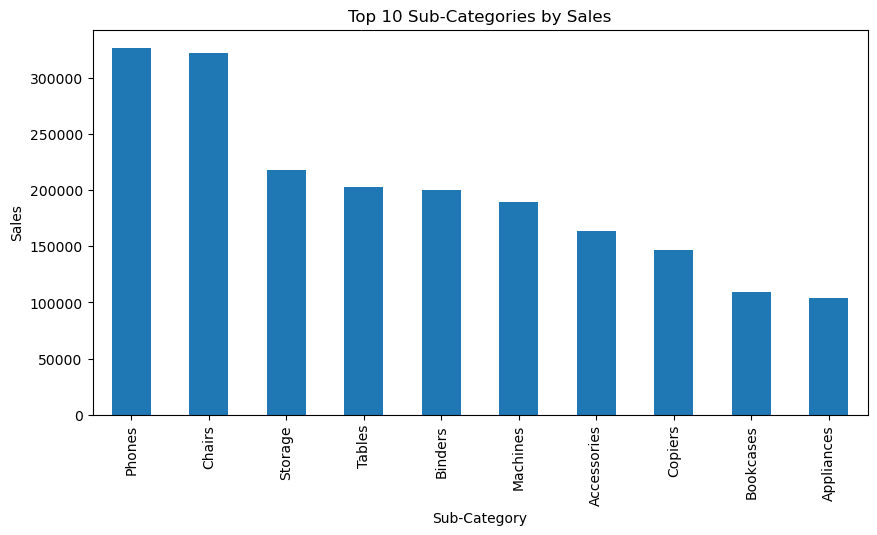

In [21]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Sub-Categories by Sales")

plt.ylabel("Sales")

plt.show()

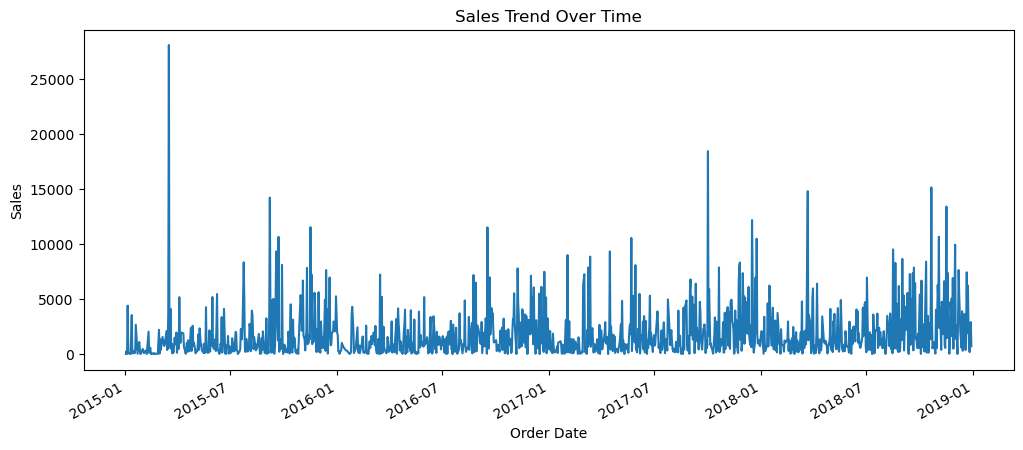

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,5))

sales_trend.plot()

plt.title("Sales Trend Over Time")

plt.ylabel("Sales")

plt.show()

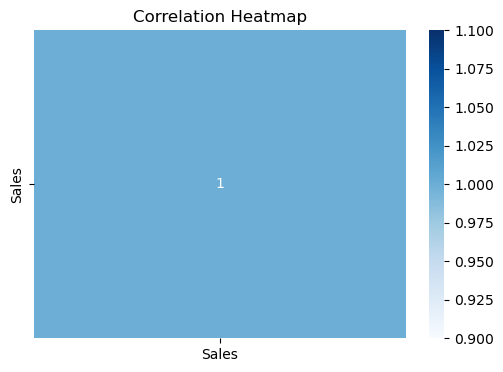

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['Sales']].corr(), annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
import os

print(os.getcwd())

C:\Users\syedm\OneDrive\Desktop\Retail_Pulse\notebooks


In [13]:
import pandas as pd

df = pd.read_csv("../Data/train.csv")

print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

print(sales_data.head())

  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158


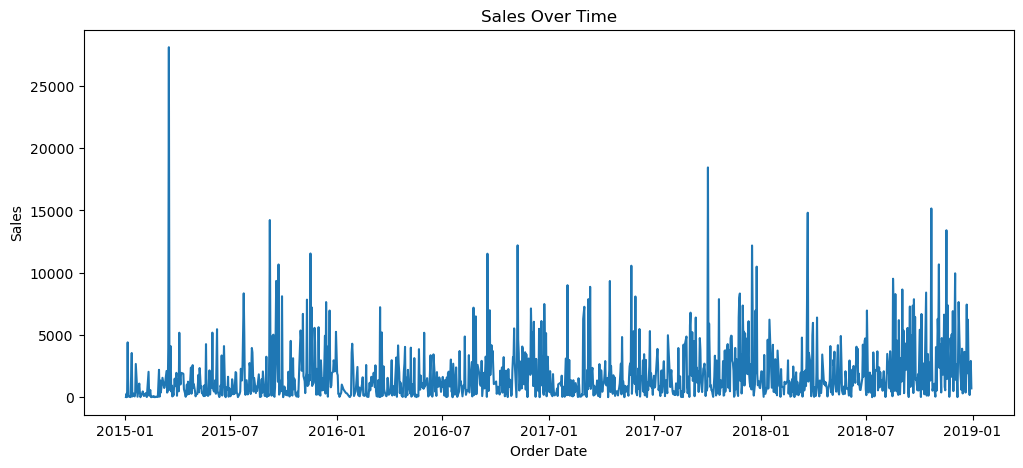

In [16]:
plt.figure(figsize=(12,5))

plt.plot(sales_data['Order Date'], sales_data['Sales'])

plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

In [17]:
from statsmodels.tsa.arima.model import ARIMA

sales_data.set_index('Order Date', inplace=True)

model = ARIMA(sales_data['Sales'], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1230
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -11298.325
Date:                Sat, 16 May 2026   AIC                          22608.651
Time:                        15:02:19   BIC                          22639.335
Sample:                             0   HQIC                         22620.196
                               - 1230                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7946      0.021    -38.726      0.000      -0.835      -0.754
ar.L2         -0.6067      0.028    -21.634      0.000      -0.662      -0.552
ar.L3         -0.4875      0.028    -17.138      0.0

C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


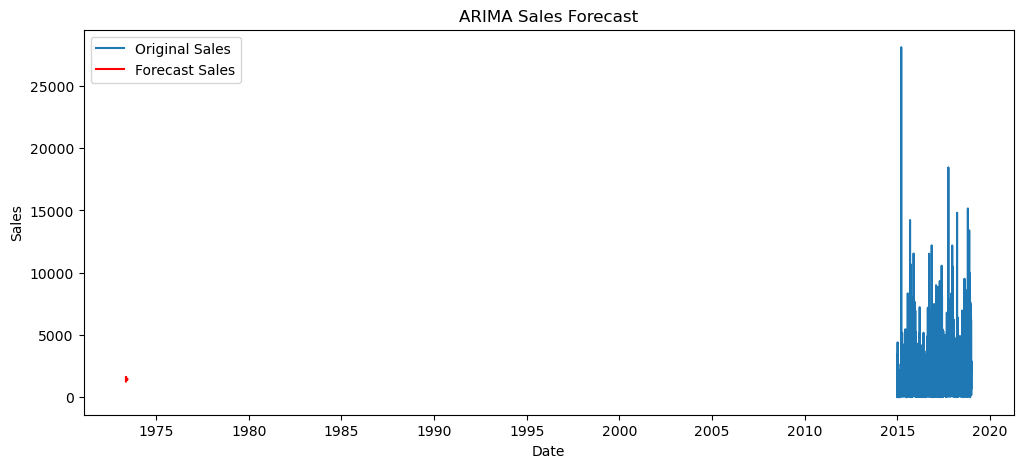

In [18]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(12,5))

plt.plot(sales_data.index, sales_data['Sales'], label='Original Sales')

plt.plot(forecast.index, forecast, label='Forecast Sales', color='red')

plt.title("ARIMA Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

C:\Users\syedm\python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


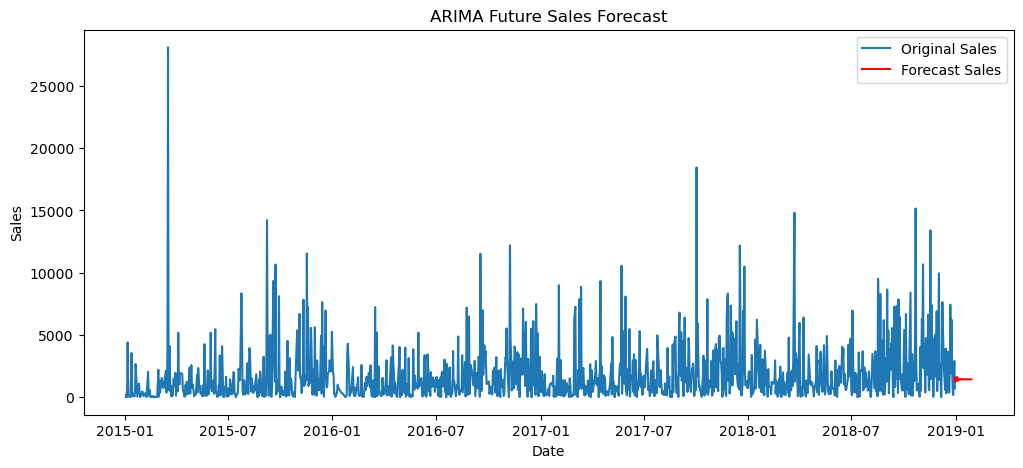

In [19]:
future_dates = pd.date_range(start=sales_data.index[-1], periods=30)

forecast = model_fit.forecast(steps=30)

forecast_series = pd.Series(forecast.values, index=future_dates)

plt.figure(figsize=(12,5))

plt.plot(sales_data.index, sales_data['Sales'], label='Original Sales')

plt.plot(forecast_series.index, forecast_series, color='red', label='Forecast Sales')

plt.title("ARIMA Future Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [20]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 4.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/12.1 MB 4.4 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.1 MB 4.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.1 MB 5.4 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 5.5 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 4.6 MB/s  0:00:02
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -----------

In [21]:
prophet_data = sales_data.reset_index()

prophet_data.columns = ['ds', 'y']

print(prophet_data.head())

          ds         y
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158


In [23]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_data)

15:13:37 - cmdstanpy - INFO - Chain [1] start processing
15:13:42 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[['ds', 'yhat']].tail()

,ds,yhat
1255,2019-01-25,1748.844356
1256,2019-01-26,2213.026500
1257,2019-01-27,1999.085719
1258,2019-01-28,1905.922143
1259,2019-01-29,2265.853224


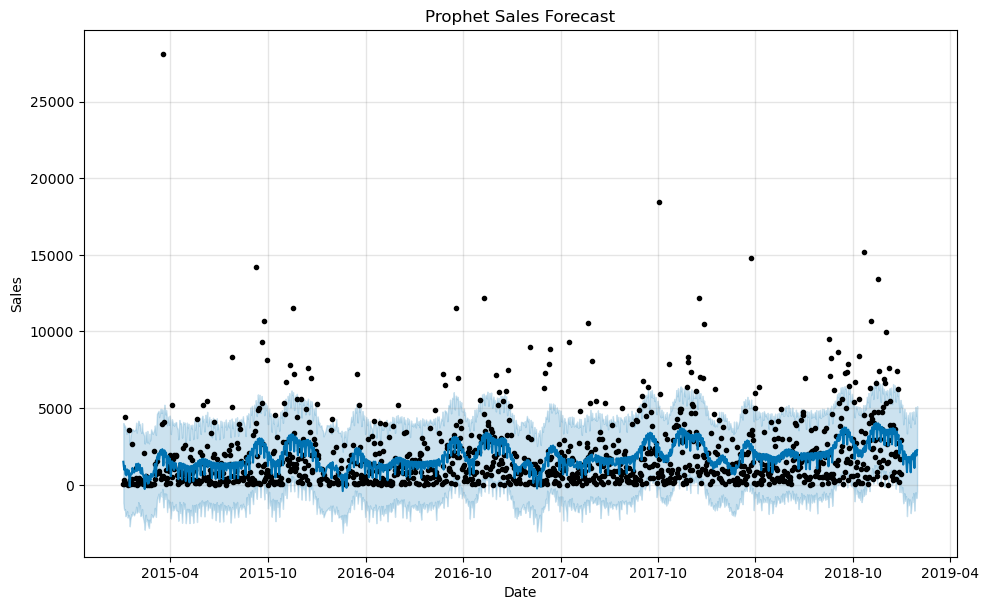

In [25]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = sales_data['Sales'][-30:]

predicted = forecast['yhat'][-30:]

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 2090.588884210341
RMSE: 2830.273503615069


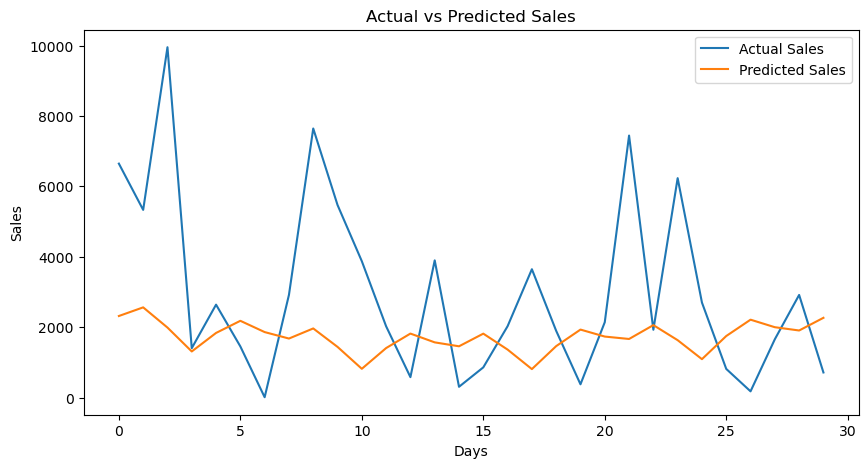

In [27]:
plt.figure(figsize=(10,5))

plt.plot(actual.values, label='Actual Sales')

plt.plot(predicted.values, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")

plt.xlabel("Days")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Customer wise total sales
customer_data = df.groupby('Customer ID')['Sales'].sum().reset_index()

print(customer_data.head())

  Customer ID     Sales
0    AA-10315  5563.560
1    AA-10375  1056.390
2    AA-10480  1790.512
3    AA-10645  5086.935
4    AB-10015   886.156


In [29]:
# Scaling the sales data

scaler = StandardScaler()

customer_data_scaled = scaler.fit_transform(customer_data[['Sales']])

print(customer_data_scaled[:5])

[[ 1.03538325]
 [-0.6855571 ]
 [-0.40525257]
 [ 0.85339695]
 [-0.75055632]]


In [30]:
# Applying KMeans clustering

kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['Cluster'] = kmeans.fit_predict(customer_data_scaled)

print(customer_data.head())

  Customer ID     Sales  Cluster
0    AA-10315  5563.560        0
1    AA-10375  1056.390        2
2    AA-10480  1790.512        2
3    AA-10645  5086.935        0
4    AB-10015   886.156        2


C:\Users\syedm\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


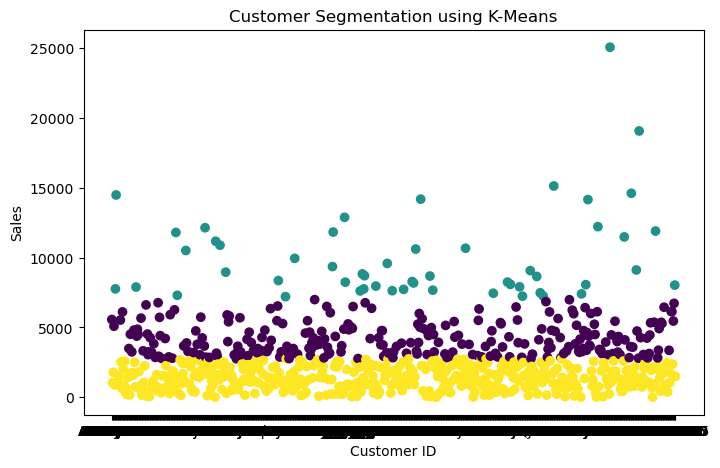

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(customer_data['Customer ID'],
            customer_data['Sales'],
            c=customer_data['Cluster'],
            cmap='viridis')

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Customer ID")

plt.ylabel("Sales")

plt.show()

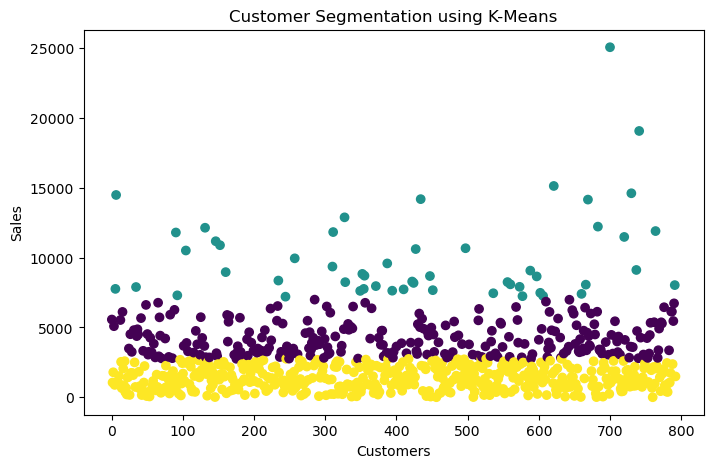

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(customer_data.index,
            customer_data['Sales'],
            c=customer_data['Cluster'],
            cmap='viridis')

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Customers")

plt.ylabel("Sales")

plt.show()

In [33]:
top_customers = customer_data.sort_values(by='Sales', ascending=False).head(10)

print(top_customers)

    Customer ID      Sales  Cluster
700    SM-20320  25043.050        1
741    TC-20980  19052.218        1
621    RB-19360  15117.339        1
730    TA-21385  14595.620        1
6      AB-10105  14473.571        1
434    KL-16645  14175.229        1
669    SC-20095  14142.334        1
327    HL-15040  12873.298        1
683    SE-20110  12209.438        1
131    CC-12370  12129.072        1


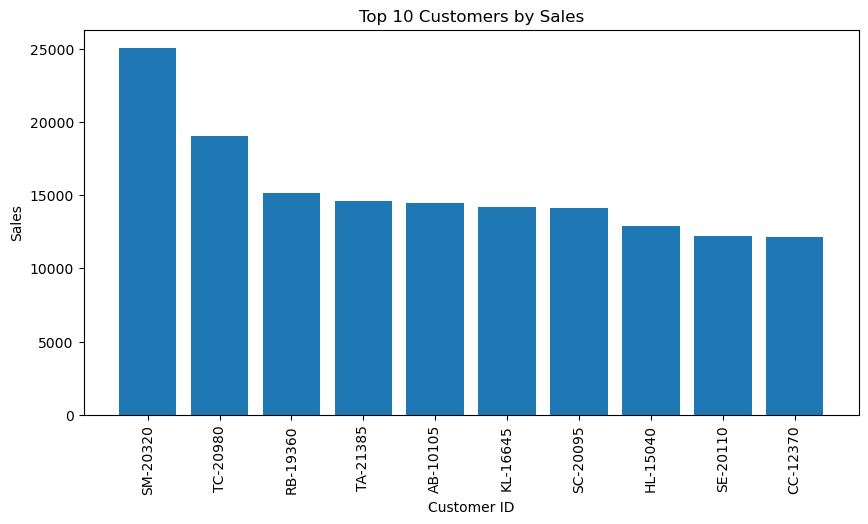

In [34]:
plt.figure(figsize=(10,5))

plt.bar(top_customers['Customer ID'],
        top_customers['Sales'])

plt.title("Top 10 Customers by Sales")

plt.xlabel("Customer ID")

plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()

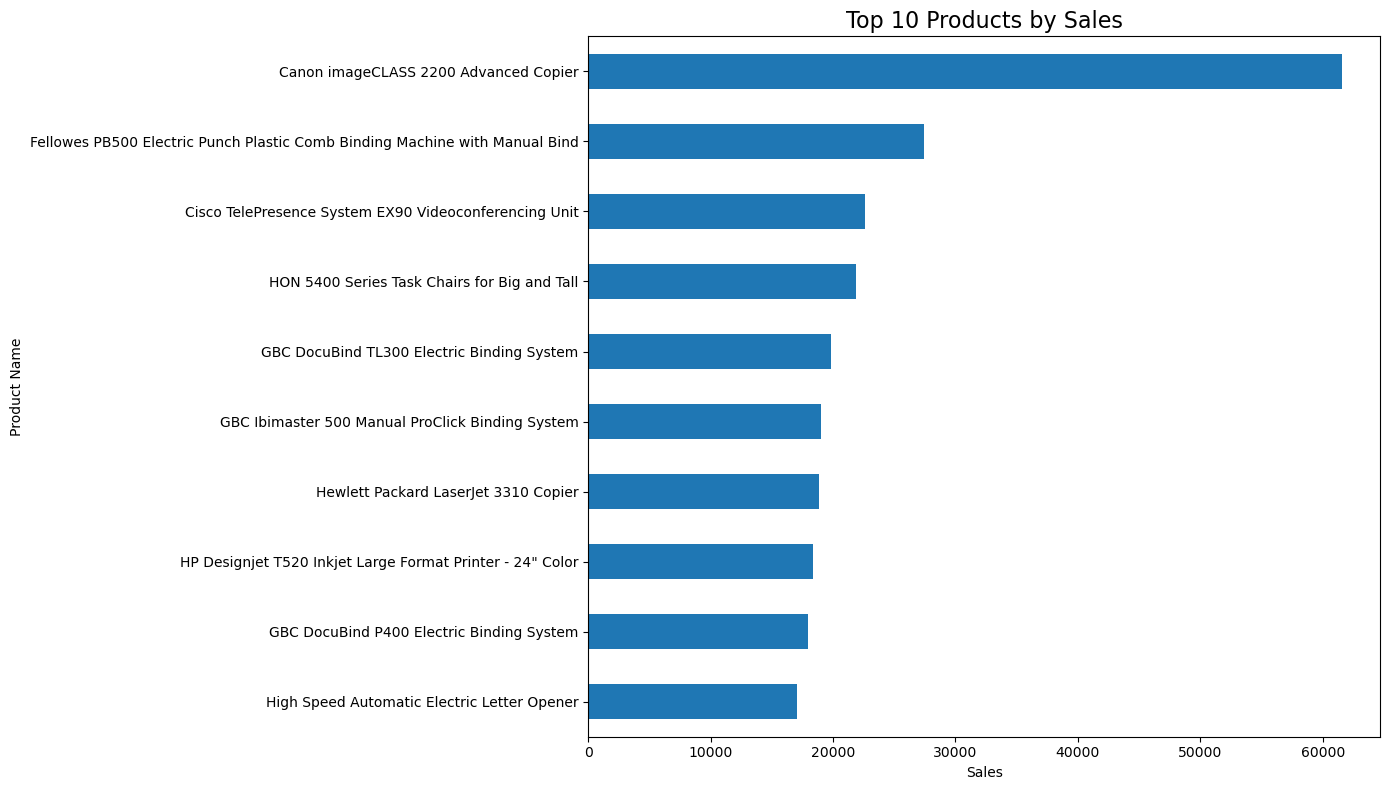

In [38]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,8))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Sales", fontsize=16)

plt.xlabel("Sales")

plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

In [39]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


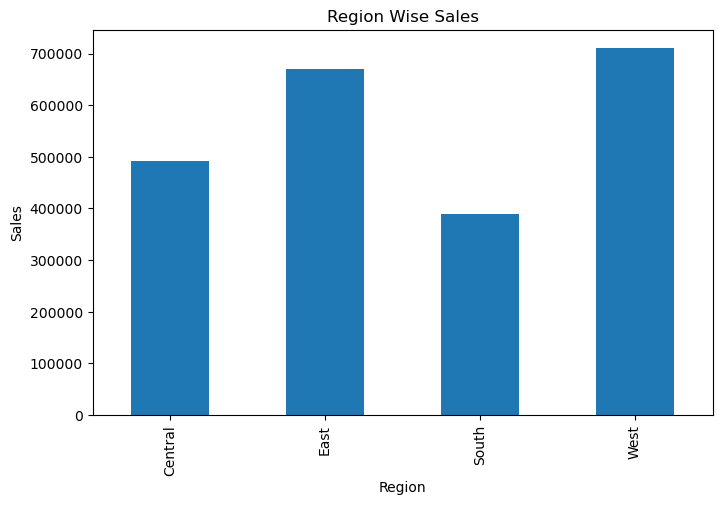

In [40]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Region Wise Sales")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

In [41]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


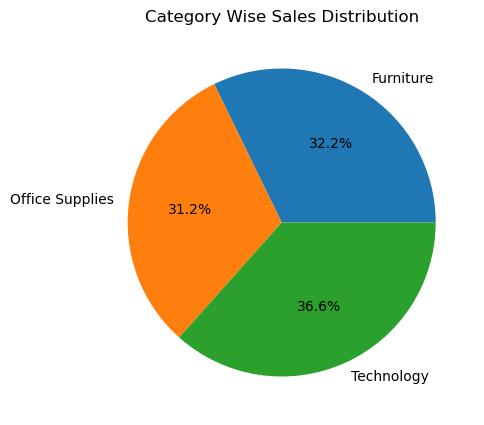

In [42]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Category Wise Sales Distribution")

plt.ylabel("")

plt.show()

In [43]:
segment_sales = df.groupby('Segment')['Sales'].sum()

print(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


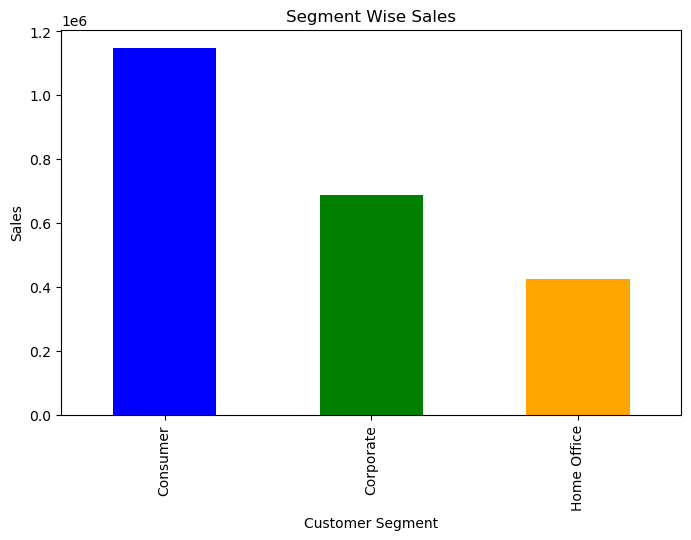

In [44]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar', color=['blue','green','orange'])

plt.title("Segment Wise Sales")

plt.xlabel("Customer Segment")

plt.ylabel("Sales")

plt.show()

In [46]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [47]:
inventory_data = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(inventory_data)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


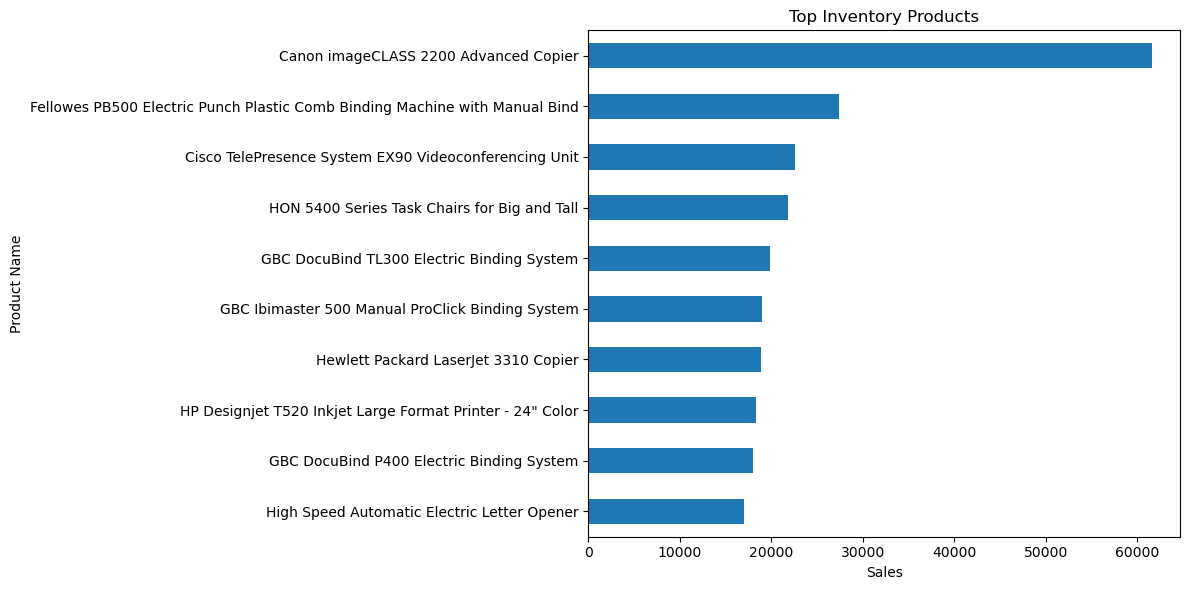

In [48]:
plt.figure(figsize=(12,6))

inventory_data.sort_values().plot(kind='barh')

plt.title("Top Inventory Products")

plt.xlabel("Sales")

plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

In [49]:
customer_sales = df.groupby('Customer ID')['Sales'].sum()

churn_customers = customer_sales[customer_sales < 500]

print(churn_customers.head())

Customer ID
AG-10300    367.548
AG-10390    200.945
AG-10765    170.584
AO-10810    161.280
AR-10510    264.864
Name: Sales, dtype: float64


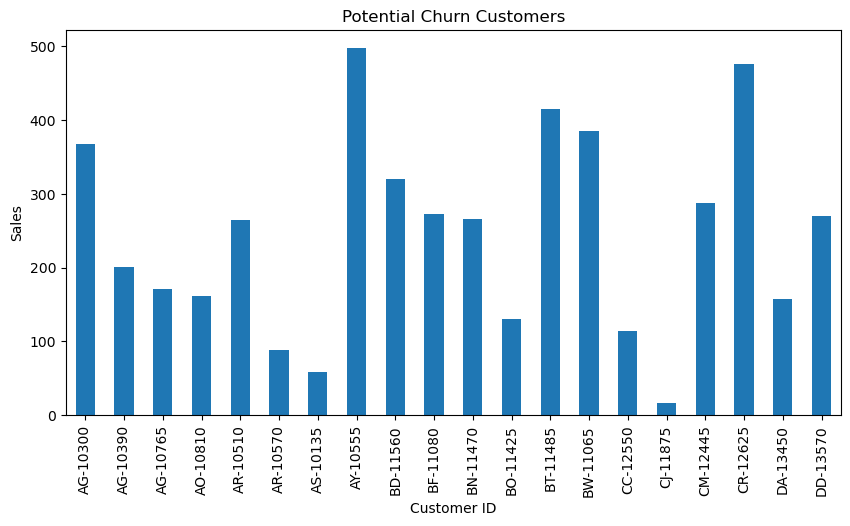

In [50]:
plt.figure(figsize=(10,5))

churn_customers.head(20).plot(kind='bar')

plt.title("Potential Churn Customers")

plt.xlabel("Customer ID")

plt.ylabel("Sales")

plt.show()

In [1]:
!pip install streamlit